## Init

In [31]:
import os
import numpy as np
import itertools as it
import random
import pandas as pd
import multiprocess as mp
import time
import sys
import matplotlib.pyplot as plt

In [32]:
folder = "C:/Users/B00955739/Documents/Git/phd/Init/"

sys.path.append(folder)

import functions_v6 as fn

Maps

In [33]:
delta = 10**(-10)
log_a = 4
tent_a = 2 - delta
tent_bs = [
    1,
    # np.exp(1)/2,
    # np.exp(2)/2,
    np.exp(4)/2
]
sluze_m = 0.8
sluze_p = 0.2
sc_params = [{"omega": 0.5, "k":2}, {"omega": np.sqrt(2), "k": 0.3}]

all_maps = []

all_maps.append(fn.log_map({"a": log_a}))
all_maps.append(fn.sluze_map({"m": sluze_m,"p": sluze_p}))

for tb in tent_bs:
    all_maps.append(fn.tent_map({"a": tent_a, "b": tb}))

for scp in sc_params:
    all_maps.append(fn.sincircle_map(scp))

Matrices

In [34]:
min_dim = 1
max_dim = 10
dims = np.arange(min_dim, max_dim + 1)

epsilons = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
]

mat_types = ["NN", "FC", "FCD", "HC", "OW", "RAND"]

gammas = [0.5, 1, 3]
reverses = [True, False]

## arguments for each matric type (passed into gen_matrix as **kwargs) - all use dim and if_print
## NN - epsilon
## FC - epsilon
## FCD - epsilon, gamma
## HC - epsilon
## OW - epsilon, reverse
## RAND - seed

Other Params

In [35]:
if_print = False

modelling_len = 10000
n_tests = 100
test_len = 100
testing_len = n_tests * test_len
discard = 10000
sim_len = modelling_len + testing_len + discard

In [36]:
print("Systems info:")
print("maps = {}".format([(mp.name, mp.params) for mp in all_maps]))
print("dims = {}".format(dims))
print("epsilons = {}".format(epsilons))
print("matrices = {}".format(mat_types))

print("Simulation info:")
print("total length = {}".format(sim_len))
print("discard length = {}".format(discard))
print("modelling length = {}".format(modelling_len))
print("testing length = {}; {} series of length {}".format(testing_len, n_tests, test_len))

Systems info:
maps = [('log_map', {'a': 4}), ('sluze_map', {'m': 0.8, 'p': 0.2}), ('tent_map', {'a': 1.9999999999, 'b': 1}), ('tent_map', {'a': 1.9999999999, 'b': 27.299075016572118}), ('sin_circle_map', {'omega': 0.5, 'k': 2}), ('sin_circle_map', {'omega': 1.4142135623730951, 'k': 0.3})]
dims = [ 1  2  3  4  5  6  7  8  9 10]
epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
matrices = ['NN', 'FC', 'FCD', 'HC', 'OW', 'RAND']
Simulation info:
total length = 30000
discard length = 10000
modelling length = 10000
testing length = 10000; 100 series of length 100


In [37]:
run_name = "main_run_v2"

In [38]:
out_folder = "C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/"

In [39]:
sim_folder = out_folder + "Sims/" + run_name + "/"
if not os.path.exists(sim_folder):
    os.makedirs(sim_folder)

In [40]:
print("CSV output: {}".format(out_folder+run_name+".csv"))
print("Simulations output: {}".format(sim_folder))

CSV output: C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/main_run_v2.csv
Simulations output: C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/Sims/main_run_v2/


In [41]:
count = 0

for d in dims:
    for map_counts in it.product(np.arange(0, d+1), repeat=len(all_maps)):
    ## map counts is a tuple (map_1_count, ..., map_N_count) where the counts are every value between 1 and dim
        if sum(map_counts) == d:
            count += 1

print(count*len(epsilons)*len(mat_types))

432378


## Define Systems

In [42]:
system_list = []
cml_list = []

sv_seed = 100
mat_seed = 200
map_shuffle_seed = 300

for d in dims:
    for e in epsilons:
        for mt in mat_types:
            for map_counts in it.product(np.arange(0, d+1), repeat=len(all_maps)):
                ## map counts is a tuple (map_1_count, ..., map_N_count) where the counts are every value between 1 and dim
                if sum(map_counts) == d:
                    
                    map_list = []
                    for map_id, map_count in enumerate(map_counts):
                        map_list.extend(map_count * [all_maps[map_id]]) ## add all_maps[map_id] to map_list map_count times
                    random.seed(map_shuffle_seed)
                    random.shuffle(map_list)
                    
                    if mt == "HC" and fn.is_base2(d) == False:
                        continue

                    gamma = random.choice(gammas)
                    reverse = random.choice(reverses)
                    
                    mat = fn.gen_matrix(typ=mt, d=d, if_print=if_print, epsilon=e, gamma=gamma, reverse=reverse, seed=mat_seed)
                    
                    cml_ = fn.CML(matrix=mat, map_list=map_list)
                    dup = False
                    if cml_ in cml_list:
                        dup = True
                    cml_list.append(cml_)
                    np.random.seed(sv_seed)
                    sv = np.round(np.random.rand(d), 5)
                    analysis_dim = np.random.randint(low=0, high=d)
                    sys_dict = {
                        "dim": d
                        ,"mat_type": mt
                        ,"epsilon": e
                        ,"map_list": map_list
                        ,"map_list_str": [(mp.name, mp.params) for mp in map_list]
                        ,"gamma": gamma
                        ,"reverse": reverse
                        ,"matrix": mat
                        ,"cml": cml_
                        ,"sv": sv
                        ,"duplicate": dup
                        ,"mat_seed": mat_seed
                        ,"sv_seed": sv_seed
                        ,"map_shuffle_seed": map_shuffle_seed
                        ,"total_sim_len": sim_len
                        ,"discard_len": discard
                        ,"modelling_len": modelling_len
                        ,"n_tests": n_tests
                        ,"test_len": test_len
                        ,"testing_len": testing_len
                        ,"analysis_dim": analysis_dim
                    }
                    
                    for map_id, map_count in enumerate(map_counts):
                        sys_dict["map_type_{}".format(map_id)] = all_maps[map_id].name
                        sys_dict["map_type_{}_params".format(map_id)] = all_maps[map_id].params
                        sys_dict["map_type_{}_count".format(map_id)] = map_count

                    sys_dict["n_unique_maps"] = len([mc for mc in map_counts if mc > 0])
                        
                    system_list.append(sys_dict)
                    mat_seed += 1
                    sv_seed += 1
                    map_shuffle_seed += 1

for idx, s_d in enumerate(system_list):
    s_d["system_id"] = idx
    s_d["sim_file"] = sim_folder + "system_" + str(idx) + ".npy"

In [43]:
system_df = pd.DataFrame(system_list)

In [44]:
unique_sys = [s_d for s_d in system_list if not s_d["duplicate"]]
print("{} total systems".format(len(system_list)))
print("{} duplicate systems removed".format(len(system_list) - len(unique_sys)))
print("{} unique systems".format(len(unique_sys)))

373275 total systems
1231 duplicate systems removed
372044 unique systems


In [45]:
unique_sys_df = pd.DataFrame(unique_sys)
unique_sys_df.head()

,dim,mat_type,epsilon,map_list,map_list_str,gamma,reverse,matrix,cml,sv,...,map_type_3_count,map_type_4,map_type_4_params,map_type_4_count,map_type_5,map_type_5_params,map_type_5_count,n_unique_maps,system_id,sim_file
0,1,NN,0.1,[sin_circle_map],"[(sin_circle_map, {'omega': 1.4142135623730951...",3.0,False,[[1.0]],<functions_v6.CML object at 0x00000298259F4A50>,[0.5434],...,0,sin_circle_map,"{'omega': 0.5, 'k': 2}",0,sin_circle_map,"{'omega': 1.4142135623730951, 'k': 0.3}",1,1,0,C:/Users/B00955739/OneDrive - Ulster Universit...
1,1,NN,0.1,[sin_circle_map],"[(sin_circle_map, {'omega': 0.5, 'k': 2})]",1.0,False,[[1.0]],<functions_v6.CML object at 0x00000298259F4710>,[0.5164],...,0,sin_circle_map,"{'omega': 0.5, 'k': 2}",1,sin_circle_map,"{'omega': 1.4142135623730951, 'k': 0.3}",0,1,1,C:/Users/B00955739/OneDrive - Ulster Universit...
2,1,NN,0.1,[tent_map],"[(tent_map, {'a': 1.9999999999, 'b': 27.299075...",3.0,False,[[1.0]],<functions_v6.CML object at 0x00000298259F4890>,[0.59768],...,1,sin_circle_map,"{'omega': 0.5, 'k': 2}",0,sin_circle_map,"{'omega': 1.4142135623730951, 'k': 0.3}",0,1,2,C:/Users/B00955739/OneDrive - Ulster Universit...
3,1,NN,0.1,[tent_map],"[(tent_map, {'a': 1.9999999999, 'b': 1})]",0.5,True,[[1.0]],<functions_v6.CML object at 0x00000298259F4650>,[0.43211],...,0,sin_circle_map,"{'omega': 0.5, 'k': 2}",0,sin_circle_map,"{'omega': 1.4142135623730951, 'k': 0.3}",0,1,3,C:/Users/B00955739/OneDrive - Ulster Universit...
4,1,NN,0.1,[sluze_map],"[(sluze_map, {'m': 0.8, 'p': 0.2})]",0.5,True,[[1.0]],<functions_v6.CML object at 0x00000298259F4250>,[0.14792],...,0,sin_circle_map,"{'omega': 0.5, 'k': 2}",0,sin_circle_map,"{'omega': 1.4142135623730951, 'k': 0.3}",0,1,4,C:/Users/B00955739/OneDrive - Ulster Universit...


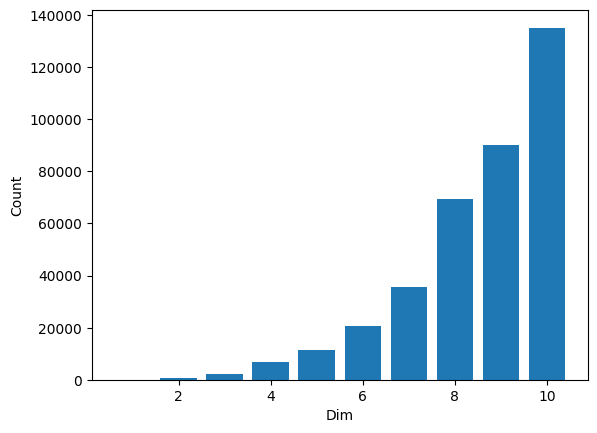

In [46]:
dim_arr = unique_sys_df.dim.to_numpy()
unique_dims, unique_counts = np.unique(dim_arr, return_counts=True)

plt.figure()
plt.bar(unique_dims, unique_counts)
plt.xlabel("Dim")
plt.ylabel("Count")
plt.show()
plt.close()

## Simulate Systems and Calculate Metrics

In [47]:
start_time = time.time()
pool = mp.Pool()
results = [pool.apply_async(fn.sim_system, args=(s_d,)) for s_d in unique_sys]
pool.close()
pool.join()
final_results = [result.get() for result in results]
end_time = time.time()
run_time = end_time-start_time
print("Full run time: {}s ({} hrs)".format(round(run_time, 4), round(run_time/(60*60), 4)))

Full run time: 508722.801s (141.3119 hrs)


In [48]:
results_df = pd.DataFrame(final_results)

In [49]:
results_df.head()

,dim,mat_type,epsilon,map_list,map_list_str,gamma,reverse,matrix,cml,sv,...,full_system_time,lyap_1,lyap_2,lyap_3,lyap_4,lyap_5,lyap_6,lyap_7,lyap_8,lyap_9
0,1,NN,0.1,[sin_circle_map],"[(sin_circle_map, {'omega': 1.4142135623730951...",3.0,False,[[1.0]],<functions_v6.CML object at 0x000002990D8C3510>,[0.5434],...,19.015723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NN,0.1,[sin_circle_map],"[(sin_circle_map, {'omega': 0.5, 'k': 2})]",1.0,False,[[1.0]],<functions_v6.CML object at 0x000002990D8CA6D0>,[0.5164],...,21.796275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,NN,0.1,[tent_map],"[(tent_map, {'a': 1.9999999999, 'b': 27.299075...",3.0,False,[[1.0]],<functions_v6.CML object at 0x000002990D8B6350>,[0.59768],...,24.826407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,NN,0.1,[tent_map],"[(tent_map, {'a': 1.9999999999, 'b': 1})]",0.5,True,[[1.0]],<functions_v6.CML object at 0x00000298D48FCB10>,[0.43211],...,26.599700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,NN,0.1,[sluze_map],"[(sluze_map, {'m': 0.8, 'p': 0.2})]",0.5,True,[[1.0]],<functions_v6.CML object at 0x00000298D48F8910>,[0.14792],...,23.988607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
print("Saving csv: {}".format(out_folder+run_name+".csv"))

results_df.to_csv(out_folder+run_name+".csv")

Saving csv: C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/main_run_v2.csv


In [51]:
print("real time: {}".format(round(run_time, 4)))
print("CPU time: {}".format(round(results_df.full_system_time.sum(), 4)))

real time: 508722.801
CPU time: 11392324.5488
